In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [ ]:
!pip install openmm

In [ ]:
!conda install -y -c conda-forge openmm pdbfixer

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

In [ ]:
!conda install -y -c conda-forge openmm pdbfixer

In [ ]:
!pip install -q openmm pdbfixer

from pdbfixer import PDBFixer
import openmm as mm
import openmm.app as app
import openmm.unit as unit

print("Step 1: Fixing missing terminal caps, heavy atoms, and hydrogens...")
fixer = PDBFixer(filename='/kaggle/input/datasets/muhammadanasamer/mhc2vtnfinal/mhc2_vtn_complex_fixed.pdb')
fixer.findMissingResidues()
fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(7.0)

print("Step 2: Saving the repaired PDB for your records...")
with open('/kaggle/working/mhc2_vtn_repaired.pdb', 'w') as f:
    app.PDBFile.writeFile(fixer.topology, fixer.positions, f)

print("Step 3: Loading Amber14SB forcefield and OBC2 implicit solvent...")
forcefield = app.ForceField('amber14-all.xml', 'implicit/obc2.xml')

print("Step 4: Creating the molecular system from the fixed topology...")
system = forcefield.createSystem(fixer.topology, 
                                 nonbondedMethod=app.NoCutoff, 
                                 constraints=app.HBonds)

print("Step 5: Setting up the Langevin integrator (300 K)...")
integrator = mm.LangevinMiddleIntegrator(300*unit.kelvin, 
                                         1/unit.picosecond, 
                                         2.0*unit.femtoseconds)

print("Step 6: Auto-detecting the fastest available GPU platform...")
best_platform = None
max_speed = 0
for i in range(mm.Platform.getNumPlatforms()):
    p = mm.Platform.getPlatform(i)
    if p.getSpeed() > max_speed:
        max_speed = p.getSpeed()
        best_platform = p

print(f"Successfully bound to Platform: {best_platform.getName()}")
simulation = app.Simulation(fixer.topology, system, integrator, best_platform)
simulation.context.setPositions(fixer.positions)

print("Step 7: Performing energy minimization to remove steric clashes...")
simulation.minimizeEnergy()

print("Saving minimized structure...")
positions = simulation.context.getState(getPositions=True).getPositions()
with open('/kaggle/working/minimized_mhc2_complex.pdb', 'w') as f:
    app.PDBFile.writeFile(simulation.topology, positions, f)

print("Minimization complete! The complex is successfully capped and saved.")

In [ ]:
import openmm as mm
import openmm.app as app
import openmm.unit as unit
import sys

print("Loading minimized MHC-II complex...")
pdb = app.PDBFile('/kaggle/working/minimized_mhc2_complex.pdb')

print("Loading Amber14SB forcefield and OBC2 implicit solvent...")
forcefield = app.ForceField('amber14-all.xml', 'implicit/obc2.xml')

print("Creating the molecular system...")
system = forcefield.createSystem(pdb.topology, 
                                 nonbondedMethod=app.NoCutoff, 
                                 constraints=app.HBonds)

print("Setting up the Langevin integrator (300 K)...")
integrator = mm.LangevinMiddleIntegrator(300*unit.kelvin, 
                                         1/unit.picosecond, 
                                         2.0*unit.femtoseconds)

print("Auto-detecting the fastest available GPU platform...")
best_platform = None
max_speed = 0
for i in range(mm.Platform.getNumPlatforms()):
    p = mm.Platform.getPlatform(i)
    if p.getSpeed() > max_speed:
        max_speed = p.getSpeed()
        best_platform = p

print(f"Successfully bound to Platform: {best_platform.getName()}")
simulation = app.Simulation(pdb.topology, system, integrator, best_platform)
simulation.context.setPositions(pdb.positions)

print("Assigning initial atom velocities for 300 K...")
simulation.context.setVelocitiesToTemperature(300*unit.kelvin)

print("Starting 100 ps thermal equilibration...")
simulation.reporters.append(app.StateDataReporter(sys.stdout, 5000, step=True, 
                                                  potentialEnergy=True, temperature=True, speed=True))
simulation.step(50000)

print("Saving equilibrated structure...")
positions = simulation.context.getState(getPositions=True).getPositions()
with open('/kaggle/working/equilibrated_mhc2_complex.pdb', 'w') as f:
    app.PDBFile.writeFile(simulation.topology, positions, f)

print("Equilibration complete! The structure is saved as equilibrated_mhc2_complex.pdb")

In [ ]:
import openmm as mm
import openmm.app as app
import openmm.unit as unit
import sys
import os

print("Loading the equilibrated MHC-II/Vitronectin complex...")
pdb = app.PDBFile('/kaggle/working/equilibrated_mhc2_complex.pdb')

print("Loading Amber14SB forcefield and OBC2 implicit solvent...")
forcefield = app.ForceField('amber14-all.xml', 'implicit/obc2.xml')

print("Creating the molecular system...")
system = forcefield.createSystem(pdb.topology, 
                                 nonbondedMethod=app.NoCutoff, 
                                 constraints=app.HBonds)

print("Setting up the Langevin integrator (300 K)...")
integrator = mm.LangevinMiddleIntegrator(300*unit.kelvin, 
                                         1/unit.picosecond, 
                                         2.0*unit.femtoseconds)

print("Auto-detecting the fastest available GPU platform...")
best_platform = None
max_speed = 0
for i in range(mm.Platform.getNumPlatforms()):
    p = mm.Platform.getPlatform(i)
    if p.getSpeed() > max_speed:
        max_speed = p.getSpeed()
        best_platform = p

print(f"Successfully bound to Platform: {best_platform.getName()}")
simulation = app.Simulation(pdb.topology, system, integrator, best_platform)
simulation.context.setPositions(pdb.positions)

print("Setting up data reporters for the 40 ns trajectory...")
# Save trajectory frames every 50,000 steps
simulation.reporters.append(app.DCDReporter('/kaggle/working/mhc2_vtn_40ns.dcd', 50000))

# Print live progress to the screen
simulation.reporters.append(app.StateDataReporter(sys.stdout, 50000, step=True, 
                                                  potentialEnergy=True, temperature=True, speed=True, 
                                                  progress=True, totalSteps=20000000))

# NEW: Save a highly secure checkpoint every 50,000 steps
simulation.reporters.append(app.CheckpointReporter('/kaggle/working/mhc2_checkpoint.chk', 50000))

print("Executing 40 ns production simulation for the MPhil thesis vaccine candidate...")
simulation.step(20000000)

print("Saving final MHC-II complex coordinates...")
positions = simulation.context.getState(getPositions=True).getPositions()
with open('/kaggle/working/mhc2_vtn_final.pdb', 'w') as f:
    app.PDBFile.writeFile(simulation.topology, positions, f)

print("Production run complete! Trajectory saved as mhc2_vtn_40ns.dcd")

In [ ]:
import openmm as mm
import openmm.app as app
import openmm.unit as unit
import sys

print("Loading the original MHC-II topology...")
pdb = app.PDBFile('/kaggle/working/equilibrated_mhc2_complex.pdb')

print("Loading Amber14SB forcefield and OBC2 implicit solvent...")
forcefield = app.ForceField('amber14-all.xml', 'implicit/obc2.xml')

print("Rebuilding the molecular system...")
system = forcefield.createSystem(pdb.topology, 
                                 nonbondedMethod=app.NoCutoff, 
                                 constraints=app.HBonds)

print("Setting up the Langevin integrator (300 K)...")
integrator = mm.LangevinMiddleIntegrator(300*unit.kelvin, 
                                         1/unit.picosecond, 
                                         2.0*unit.femtoseconds)

print("Binding to the GPU...")
best_platform = None
max_speed = 0
for i in range(mm.Platform.getNumPlatforms()):
    p = mm.Platform.getPlatform(i)
    if p.getSpeed() > max_speed:
        max_speed = p.getSpeed()
        best_platform = p

simulation = app.Simulation(pdb.topology, system, integrator, best_platform)

print("Loading the latest checkpoint data...")
# This restores all exact atom positions, velocities, and the step counter
simulation.loadCheckpoint('/kaggle/working/mhc2_checkpoint.chk')

print("Reattaching trajectory reporters...")
# CRITICAL: append=True ensures we add to your existing 15.9+ MiB file
simulation.reporters.append(app.DCDReporter('/kaggle/working/mhc2_vtn_40ns.dcd', 50000, append=True))

# This brings the live text cycle back to your screen
simulation.reporters.append(app.StateDataReporter(sys.stdout, 50000, step=True, 
                                                  potentialEnergy=True, temperature=True, speed=True, 
                                                  progress=True, totalSteps=20000000))

# Keep saving checkpoints just in case
simulation.reporters.append(app.CheckpointReporter('/kaggle/working/mhc2_checkpoint.chk', 50000))

# Calculate exactly how many steps are left to hit the 40 ns target
current_step = simulation.context.getState().getStepCount()
remaining_steps = 20000000 - current_step

print(f"Resuming simulation for the remaining {remaining_steps} steps...")
simulation.step(remaining_steps)

print("Saving final MHC-II complex coordinates...")
positions = simulation.context.getState(getPositions=True).getPositions()
with open('/kaggle/working/mhc2_vtn_final.pdb', 'w') as f:
    app.PDBFile.writeFile(simulation.topology, positions, f)

print("Production run complete! Trajectory safely finished.")

In [ ]:
!pip install MDAnalysis matplotlib numpy

In [ ]:
import MDAnalysis as mda
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the MHC-II/Vitronectin complex topology and 40 ns trajectory
print("Loading trajectory into MDAnalysis...")
pdb_file = '/kaggle/working/equilibrated_mhc2_complex.pdb'
dcd_file = '/kaggle/working/mhc2_vtn_40ns.dcd'
u = mda.Universe(pdb_file, dcd_file)

# 2. RMSD Calculation (System Stability)
print("Calculating RMSD...")
R = rms.RMSD(u, u, select='backbone', groupselections=['protein'])
R.run()

# Create time array: (50,000 steps * 2 fs = 100 ps = 0.1 ns per frame)
time_ns = R.results.rmsd[:, 1] * 0.1 
rmsd_values = R.results.rmsd[:, 2] # Values in Angstroms

# Plot RMSD
plt.figure(figsize=(10, 5))
plt.plot(time_ns, rmsd_values, color='blue', linewidth=2)
plt.title('MHC-II / Vitronectin Complex Backbone RMSD (40 ns)', fontsize=14, fontweight='bold')
plt.xlabel('Time (ns)', fontsize=12)
plt.ylabel('RMSD (Å)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 40)
plt.savefig('/kaggle/working/mhc2_rmsd_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. RMSF Calculation (Residue Flexibility)
print("Calculating RMSF...")
calphas = u.select_atoms('name CA')
rmsf = rms.RMSF(calphas).run()

# Plot RMSF
plt.figure(figsize=(10, 5))
plt.plot(calphas.resids, rmsf.results.rmsf, color='red', linewidth=1.5)
plt.title('MHC-II / Vitronectin Complex Per-Residue RMSF', fontsize=14, fontweight='bold')
plt.xlabel('Residue Number', fontsize=12)
plt.ylabel('RMSF (Å)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('/kaggle/working/mhc2_rmsf_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Analysis complete! High-resolution PNG plots saved to /kaggle/working/")

In [ ]:
!pip install mdtraj matplotlib numpy

In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

print("Loading trajectory and topology...")
pdb_file = '/kaggle/working/equilibrated_mhc2_complex.pdb'
dcd_file = '/kaggle/working/mhc2_vtn_40ns.dcd'

# Load trajectory
traj = md.load(dcd_file, top=pdb_file)

# Create time array (assuming 0.1 ns per frame based on 50,000 steps)
time_ns = np.arange(len(traj)) * 0.1 

# 1. Backbone RMSD
print("Calculating RMSD...")
traj.superpose(traj, 0)
rmsd = md.rmsd(traj, traj, 0) * 10  # nm to Å
plt.figure(figsize=(8,5))
plt.plot(time_ns, rmsd, color='blue', linewidth=1.5)
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.title("MHC-II / Vitronectin Backbone RMSD")
plt.tight_layout()
plt.savefig("/kaggle/working/RMSD.png", dpi=300)
plt.close()

# 2. C-Alpha RMSF
print("Calculating RMSF...")
ca_indices = traj.topology.select('name CA')
rmsf = md.rmsf(traj, traj, 0, atom_indices=ca_indices) * 10  # nm to Å
residues = np.arange(len(ca_indices))
plt.figure(figsize=(8,5))
plt.plot(residues, rmsf, color='red', linewidth=1.5)
plt.xlabel("Residue Index")
plt.ylabel("RMSF (Å)")
plt.title("MHC-II / Vitronectin Cα RMSF")
plt.tight_layout()
plt.savefig("/kaggle/working/RMSF.png", dpi=300)
plt.close()

# 3. Radius of Gyration (Rg)
print("Calculating Rg...")
rg = md.compute_rg(traj) * 10  # nm to Å
plt.figure(figsize=(8,5))
plt.plot(time_ns, rg, color='green', linewidth=1.5)
plt.xlabel("Time (ns)")
plt.ylabel("Radius of Gyration (Å)")
plt.title("MHC-II / Vitronectin Radius of Gyration")
plt.tight_layout()
plt.savefig("/kaggle/working/Rg.png", dpi=300)
plt.close()

# 4. SASA (Solvent Accessible Surface Area)
print("Calculating SASA...")
# Downsample if the system is too large and crashes memory, otherwise run normally
sasa = md.shrake_rupley(traj)
sasa_total = np.sum(sasa, axis=1) # Total SASA in nm²
plt.figure(figsize=(8,5))
plt.plot(time_ns, sasa_total, color='purple', linewidth=1.5)
plt.xlabel("Time (ns)")
plt.ylabel("SASA (nm²)")
plt.title("MHC-II / Vitronectin Solvent Accessible Surface Area")
plt.tight_layout()
plt.savefig("/kaggle/working/SASA.png", dpi=300)
plt.close()

print("All plots generated! Check the /kaggle/working/ folder.")

In [ ]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("Loading trajectory and superposing...")
pdb_file = '/kaggle/working/equilibrated_mhc2_complex.pdb'
dcd_file = '/kaggle/working/mhc2_vtn_40ns.dcd'

# Load and align trajectory to the first frame
traj = md.load(dcd_file, top=pdb_file)
traj.superpose(traj, 0)

# Create time array (0.1 ns per frame)
time_ns = np.arange(len(traj)) * 0.1 

# ---------------------------------------------------------
# 1. Hydrogen Bond Analysis
# ---------------------------------------------------------
print("Calculating Hydrogen Bonds...")
# Wernet-Nilsson calculates H-bonds per frame (excluding implicit water)
hbonds = md.wernet_nilsson(traj, exclude_water=True)
hbond_counts = [len(frame) for frame in hbonds]

plt.figure(figsize=(8,5))
plt.plot(time_ns, hbond_counts, color='orange', linewidth=1.5)
plt.xlabel("Time (ns)")
plt.ylabel("Number of H-Bonds")
plt.title("MHC-II / Vitronectin Hydrogen Bonds")
plt.tight_layout()
plt.savefig("/kaggle/working/Hbonds.png", dpi=300)
plt.close()
print("Hbonds.png generated.")

# ---------------------------------------------------------
# 2. Principal Component Analysis (PCA)
# ---------------------------------------------------------
print("Calculating PCA (C-alpha atoms)...")
# Select only C-alpha backbone atoms to isolate main folding motions
ca_indices = traj.topology.select('name CA')
traj_ca = traj.atom_slice(ca_indices)

# Flatten coordinates from 3D (frames, atoms, xyz) to 2D (frames, atoms*3)
xyz2d = traj_ca.xyz.reshape(traj_ca.n_frames, traj_ca.n_atoms * 3)

# Perform PCA to extract the top 2 dominant motions (PC1 and PC2)
pca = PCA(n_components=2)
reduced_cartesian = pca.fit_transform(xyz2d)

plt.figure(figsize=(8,5))
# Scatter plot colored by time progression to show conformational shifts
scatter = plt.scatter(reduced_cartesian[:, 0], reduced_cartesian[:, 1], 
                      c=time_ns, cmap='viridis', marker='o', alpha=0.7, edgecolors='none')
cbar = plt.colorbar(scatter)
cbar.set_label('Time (ns)')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("MHC-II / Vitronectin PCA Projection")
plt.tight_layout()
plt.savefig("/kaggle/working/PCA.png", dpi=300)
plt.close()
print("PCA.png generated.")

print("\nAnalysis complete! All final thesis plots are ready in /kaggle/working/")

In [ ]:
import shutil
from IPython.display import FileLink

print("Compressing all thesis files (Trajectories, PDBs, and Plots)...")

# Zip the entire working directory
archive_name = 'mhc2_vtn_complete_results'
shutil.make_archive(archive_name, 'zip', '/kaggle/working/')

print("Compression complete! Click the link below to download:")
# Generate a clickable download link
FileLink(f'{archive_name}.zip')

In [1]:
import mdtraj as md
import numpy as np
import matplotlib.pyplot as plt

print("Loading trajectory for COM calculation...")
pdb_file = '/kaggle/working/equilibrated_mhc2_complex.pdb'
dcd_file = '/kaggle/working/mhc2_vtn_40ns.dcd'
traj = md.load(dcd_file, top=pdb_file)

# Select the atoms for the receptor and the ligand
# (Update chainid 0, 1, and 2 based on your specific PDB structure)
print("Isolating receptor and ligand...")
receptor_indices = traj.topology.select('chainid 0 or chainid 1') 
ligand_indices = traj.topology.select('chainid 2')

if len(receptor_indices) == 0 or len(ligand_indices) == 0:
    print("Error: Chains not found. Please check your PDB chain IDs.")
else:
    # Slice the trajectory to isolate the two groups
    traj_receptor = traj.atom_slice(receptor_indices)
    traj_ligand = traj.atom_slice(ligand_indices)
    
    print("Computing Centers of Mass...")
    # Compute the center of mass for each group (returns an array of [x,y,z] per frame)
    com_receptor = md.compute_center_of_mass(traj_receptor)
    com_ligand = md.compute_center_of_mass(traj_ligand)
    
    # Calculate the Euclidean distance between the two COMs across all frames
    print("Calculating distance...")
    distances_nm = np.linalg.norm(com_receptor - com_ligand, axis=1)
    distances_A = distances_nm * 10  # Convert nanometers to Angstroms
    
    # Create time array (0.1 ns per frame)
    time_ns = np.arange(len(traj)) * 0.1 
    
    print("Plotting COM distance...")
    plt.figure(figsize=(8,5))
    plt.plot(time_ns, distances_A, color='teal', linewidth=1.5)
    plt.xlabel("Time (ns)")
    plt.ylabel("COM Distance (Å)")
    plt.title("MHC-II / Vitronectin Center of Mass Distance")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("/kaggle/working/COM_Distance.png", dpi=300)
    plt.close()
    
    print("COM_Distance.png successfully generated in /kaggle/working/!")

Loading trajectory for COM calculation...
Isolating receptor and ligand...
Computing Centers of Mass...
Calculating distance...
Plotting COM distance...
COM_Distance.png successfully generated in /kaggle/working/!


In [2]:
from IPython.display import FileLink
FileLink('/kaggle/working/COM_Distance.png')

/kaggle/working/COM_Distance.png

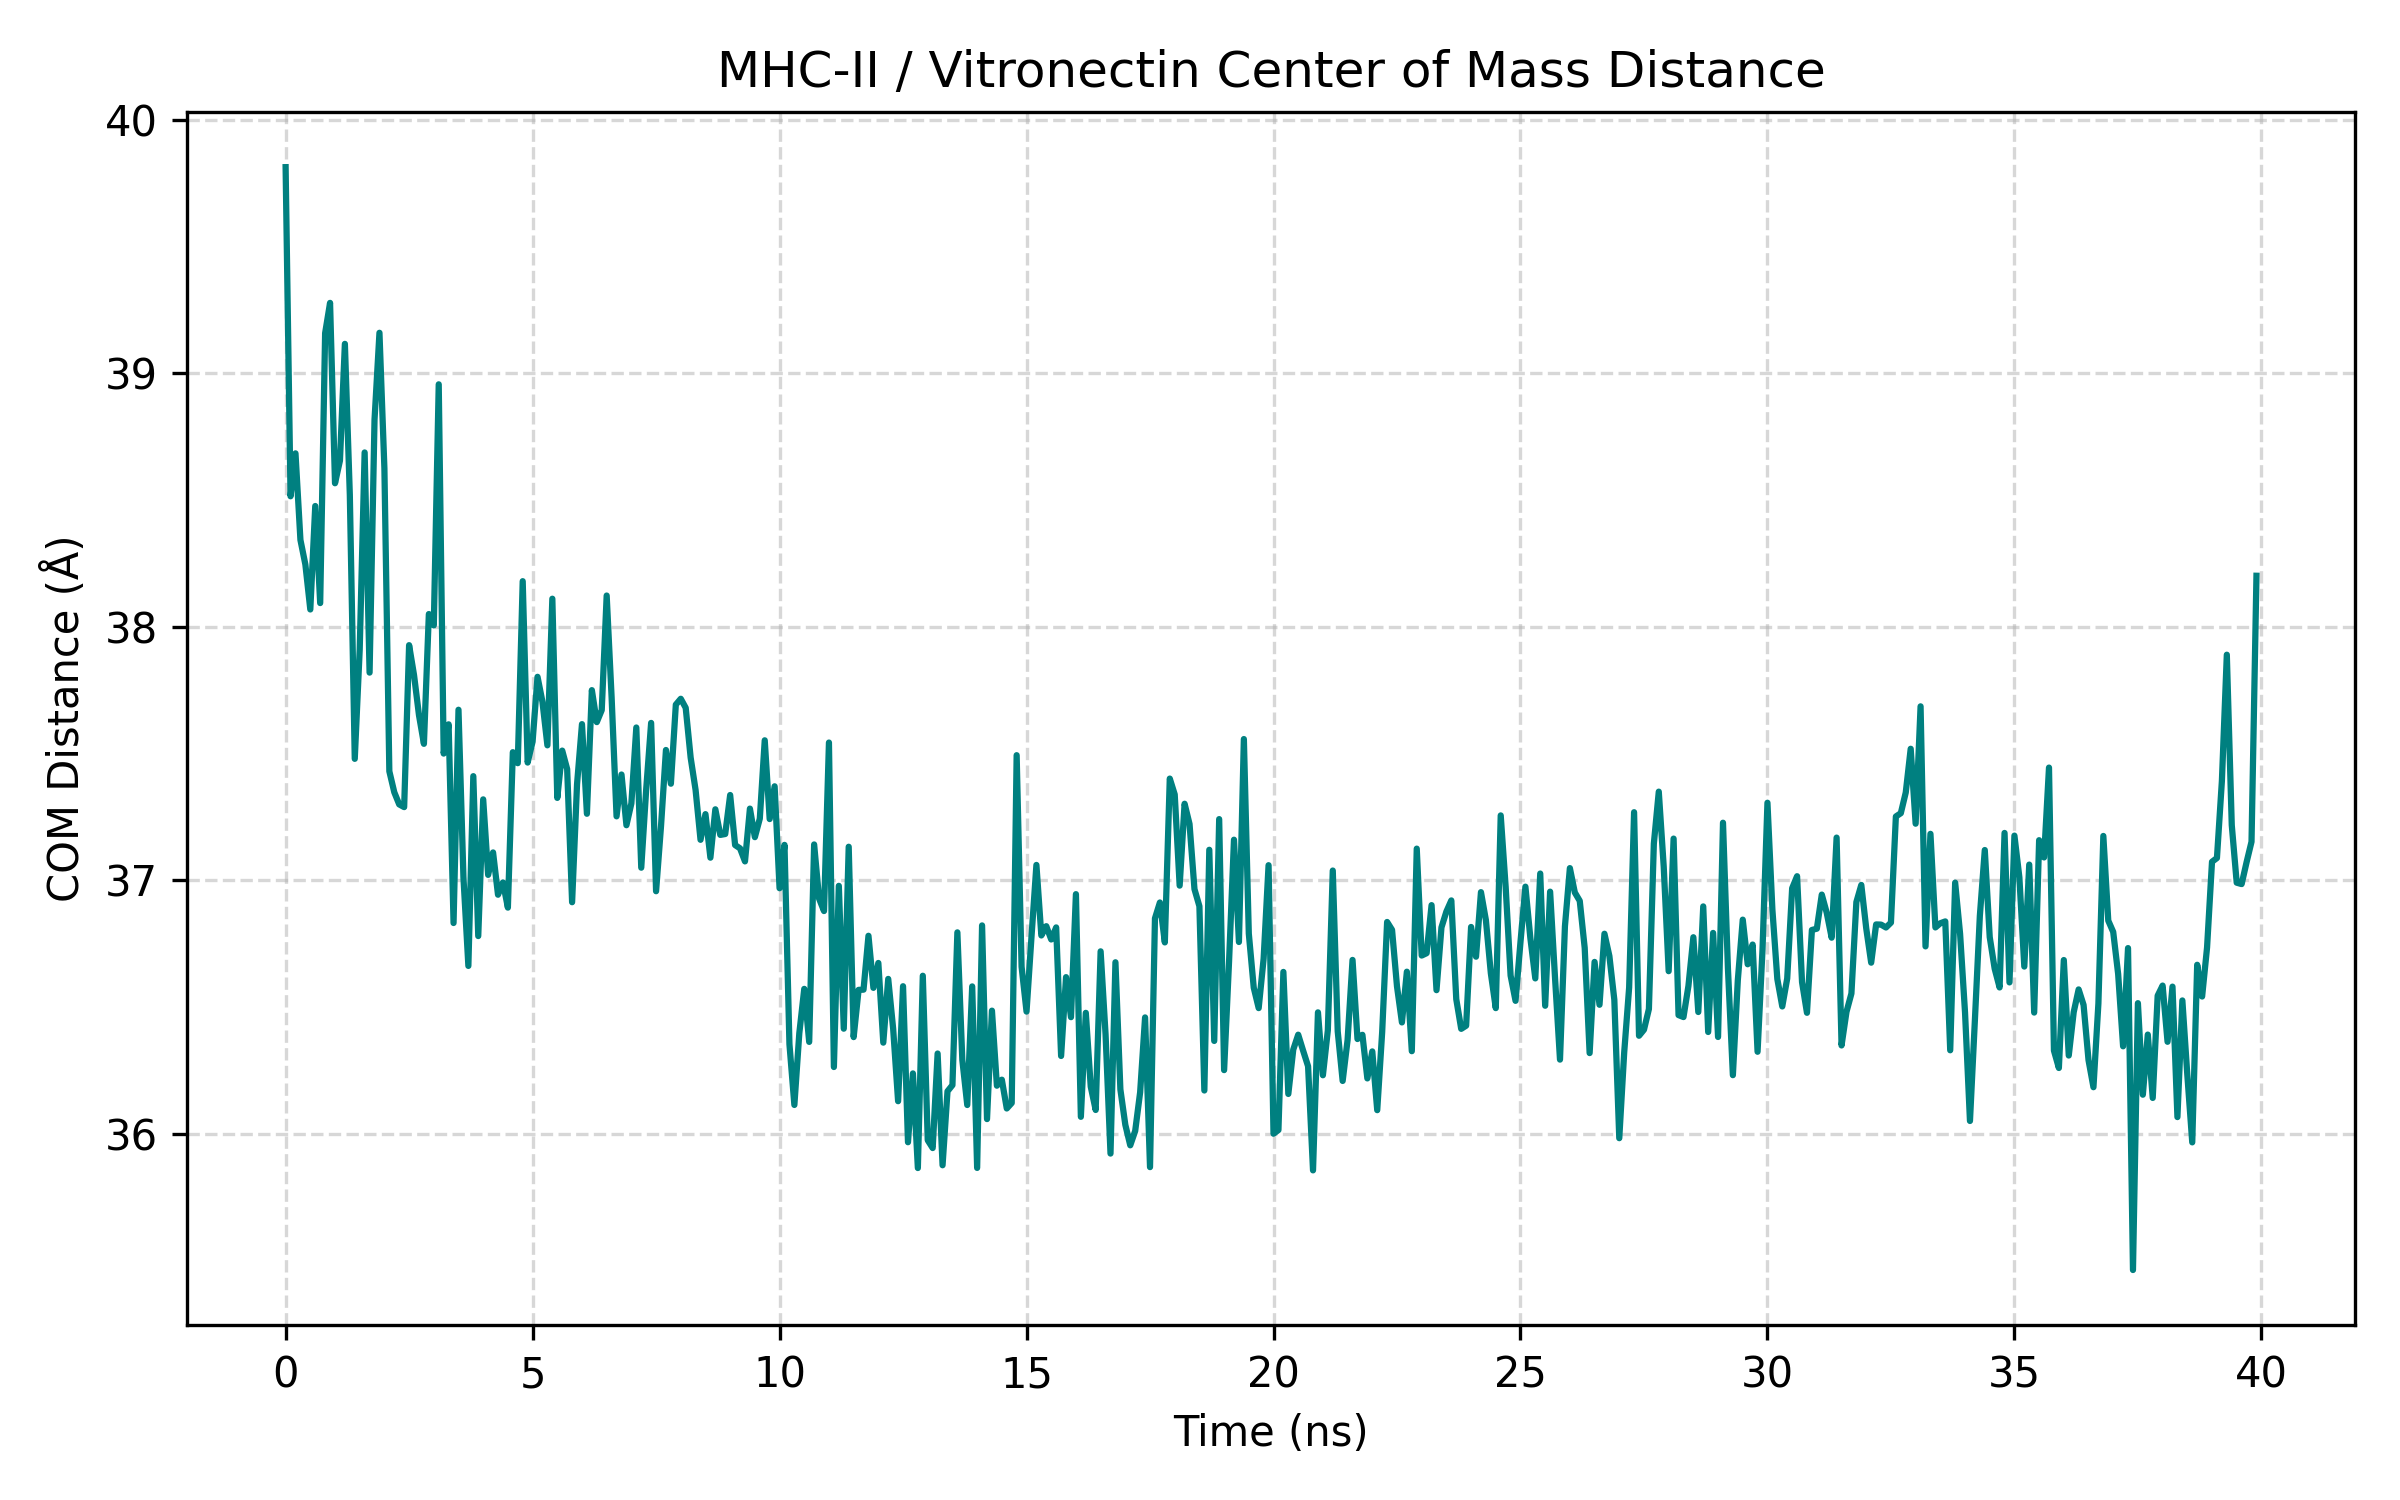

In [3]:
from IPython.display import Image
display(Image(filename='/kaggle/working/COM_Distance.png'))